In [39]:
from typing import List, TypedDict
import re

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint, HuggingFaceEndpointEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from dotenv import load_dotenv

In [ ]:
# import os
# os.environ["HUGGINGFACEHUB_API_TOKEN"] = ""

In [41]:
embedding_model = HuggingFaceEndpointEmbeddings(
    model="sentence-transformers/all-MiniLM-L6-v2",
    task="feature-extraction"
)

In [53]:
llm = HuggingFaceEndpoint(
    repo_id = "deepseek-ai/DeepSeek-V3.2", 
    task = "text-generation",
    max_new_tokens=3000,
)
model = ChatHuggingFace(llm = llm)

In [62]:
response = model.invoke("Who is the president of the United States?")
response

AIMessage(content="As of my last knowledge update in October 2023, the president of the United States is **Joe Biden**. He is the 46th president and began his term on January 20, 2021.\n\nFor the most current information, especially as elections and political events unfold, it's always a good idea to check a reliable news source.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 13, 'total_tokens': 84}, 'model_name': 'deepseek-ai/DeepSeek-V3.2', 'system_fingerprint': None, 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a10136-087f-75b3-8693-4bca88c97714-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 71, 'total_tokens': 84})

### Knowledge Refinment

In [43]:
docs = (
    PyPDFLoader("documents/book1.pdf").load()
    + PyPDFLoader("documents/book2.pdf").load()
    + PyPDFLoader("documents/book3.pdf").load()
)

In [44]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [45]:
vector_store = FAISS.from_documents(chunks, embedding_model)
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

In [46]:
class State(TypedDict):
    question: str
    docs: List[Document]

    strips: List[str]            # output of decomposition (sentence strips)
    kept_strips: List[str]       # after filtering (kept sentences)
    refined_context: str         # recomposed internal knowledge (joined kept_strips)

    answer: str

In [47]:
def retrieve(state: State) -> State:
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [48]:
len(docs)

2123

In [60]:
# Sentece level Decomposer
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# Filter (Judge LLM)
class KeepOrDrop(BaseModel):
    keep: bool

from langchain_core.output_parsers import JsonOutputParser
parser = JsonOutputParser()
filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)


filter_chain = filter_prompt | model | parser

# Refining (Decompose -> Filter -> Recompose)

def refine(state: State) -> State:
    q = state["question"]

    # Combine retrieved docs
    context = "\n\n".join(
        d.page_content for d in state["docs"]
    ).strip()

    # 1) DECOMPOSITION
    strips = decompose_to_sentences(context)

    # 2) FILTER
    # Temporary rule-based filter for testing the graph
    q_words = set(re.findall(r"\w+", q.lower()))

    kept = []

    for s in strips:
        s_words = set(re.findall(r"\w+", s.lower()))

        # Keep sentence if it shares words with the question
        if q_words.intersection(s_words):
            kept.append(s)

    # 3) RECOMPOSE
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context
    }

In [50]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided books.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    response = (answer_prompt | model).invoke({"question": state["question"], "refined_context": state['refined_context']})
    return {"answer": response.content}

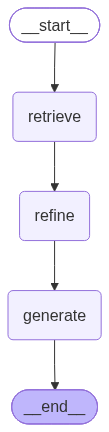

In [51]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("refine", refine)
g.add_node("generate", generate)

g.add_edge(START, "retrieve")
g.add_edge("retrieve", "refine")
g.add_edge("refine", "generate")
g.add_edge("generate", END)

graph = g.compile()

graph

In [61]:
res = graph.invoke({
    "question": "Explain the bias–variance tradeoff",
    "docs": [],
    "strips": [],
    "kept_strips": [],
    "refined_context": "",
    "answer": ""
})
print(res["answer"])

HfHubHTTPError: Client error '402 Payment Required' for url 'https://router.huggingface.co/v1/chat/completions' (Request ID: Root=1-6ac0d200-4b84f1a92d42709b0a9470b1;1fdefe06-2b5c-49d4-930c-338914c06ba5)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/402

You have depleted your monthly included credits. Purchase pre-paid credits to continue using Inference Providers. Alternatively, subscribe to PRO to get 20x more included usage.

In [ ]:
print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

In [ ]:
print(res['refined_context'])